# Apple Products Pricing (2020–2026) — Exploratory Data Analysis

## Business Problem

**Fair-market-price guidance for marketplace sellers**

- **Problem:** Individual sellers listing Apple products on Amazon or Flipkart must research the fair market price themselves to price their listings competitively — a slow, error-prone process that deters casual sellers. The platform can offer a *suggested fair price* at listing time, powered by this prediction model.
- **Business value:** lowers the barrier to listing, improves listing quality and sell-through, attracts more sellers, and grows marketplace liquidity — a platform-growth feature, not just an analytics exercise.
- **Hypothesis:** fair market price is driven by predictable depreciation — Apple products depreciate along category-specific exponential curves; condition applies a stable multiplier; festival events cause temporary, recoverable dips.
- **Target:** `Current_Price_USD` — predicted directly as the suggested fair-market listing price. The suggestion must work for *any* product a seller lists — including just-launched models — which is why the feature set is `Model_Name`-agnostic.

`Current_Price_USD` is profiled below as the sole modeling target.

| Section | Contents |
|---|---|
| 0 | Load and leakage drop |
| 1 | Feature engineering: launch-date mapping, parsed attributes, calendar features |
| 2 | Dataset overview and completeness audit |
| 3 | Target profiling: `Current_Price_USD` |
| 4 | Feature distributions, relationships to target, cardinality assessment |
| 5 | Temporal patterns: depreciation curves, seasonality, time-since-launch hypothesis test, `Reviews_Count` check |
| 6 | Data quality flags and feature-selection summary |
| 7 | Train/test split — shared baseline for predictive modeling |

## 0. Load and leakage drop

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TARGET = 'Current_Price_USD'   # target variable for prediction

df = pd.read_csv('apple_products_pricing_2020_2026.csv', parse_dates=['Date'])
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head()

Loaded 80,000 rows x 14 columns | 2020-09-19 to 2026-07-31


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


> **Note — columns dropped for leakage / redundancy.**
> `Current_Price_INR` is the target expressed in another currency (direct leakage).
> `Discount_Pct` is arithmetically derived from the target: `(1 − Current_Price_USD / Launch_Price_USD) × 100` (leakage).
> `Launch_Price_INR` is collinear with `Launch_Price_USD` (redundant — keep the USD version only).
> The cell below prints the evidence, then drops all three so no downstream analysis can accidentally use them.

In [2]:
LEAK_COLS = ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']

# Evidence before dropping
print(f"corr(Current_Price_USD, Current_Price_INR)  = {df[TARGET].corr(df['Current_Price_INR']):.4f}  -> target in INR (leakage)")
recon = (1 - df[TARGET] / df['Launch_Price_USD']) * 100
print(f"Discount_Pct vs (1 - Current/Launch)*100    : max abs diff = {(recon - df['Discount_Pct']).abs().max():.4f}  -> derived from target (leakage)")
print(f"corr(Launch_Price_USD, Launch_Price_INR)    = {df['Launch_Price_USD'].corr(df['Launch_Price_INR']):.4f}  -> redundant")

df = df.drop(columns=LEAK_COLS)
print(f"\nDropped {LEAK_COLS}")
print(f"Remaining columns: {list(df.columns)}")

corr(Current_Price_USD, Current_Price_INR)  = 0.9951  -> target in INR (leakage)
Discount_Pct vs (1 - Current/Launch)*100    : max abs diff = 0.0514  -> derived from target (leakage)
corr(Launch_Price_USD, Launch_Price_INR)    = 1.0000  -> redundant

Dropped ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']
Remaining columns: ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']


## 1. Feature engineering

- **`researched_launch_date`** — manually researched launch date per `Model_Name` (Apple's official announcement dates), mapped onto `df`. Compared below against `proxy_launch_date` (each model's first appearance in the data) to check how good a substitute the proxy is.
- **`days_since_launch`** — per-model depreciation clock, derived as days since `researched_launch_date` (falls back to the proxy for any unmapped model).
- **Model_Name-agnostic attributes** parsed from the name string, so the model can score products not in the training data (e.g., *iPhone 19 128GB*): `storage_gb`, `variant_tier` (Pro Max / Pro / Air / mini / ...), `generation` (iPhone 17 → 17, Watch Series 6 → 6, "(9th Gen)" → 9, Apple-silicon M3 → 3 as fallback; Roman numerals like Series X stay NaN — parsing is heuristic).
- **`Sale_Event` cleanup** — in the raw data, "no event" is stored as NaN (~92% of rows); it is filled with the explicit category `'None'` first, and `is_sale_event` derived from it.
- **Calendar features** — `month`, `is_sale_event`.

In [3]:
# ---- Launch date: researched (ground truth) vs proxy (first listing date) ----
researched_launch_date = {
    'Apple Watch Series 6 (44mm)': '2020-09-18',
    'iPad Air (4th Gen) 64GB': '2020-10-23',
    'iPhone 12 64GB': '2020-10-23',
    'iPhone 12 Pro 128GB': '2020-10-23',
    'MacBook Air M1 256GB': '2020-11-17',
    'iPad Pro 11-inch (M1) 128GB': '2021-05-21',
    'iPhone 13 128GB': '2021-09-24',
    'iPhone 13 Pro Max 256GB': '2021-09-24',
    'iPad (9th Gen) 64GB': '2021-09-24',
    'Apple Watch Series 7 (45mm)': '2021-10-15',
    'MacBook Pro 14-inch M1 Pro 512GB': '2021-10-26',
    'iPad Air (5th Gen) 64GB': '2022-03-18',
    'MacBook Air M2 256GB': '2022-07-15',
    'Apple Watch Series 8 (45mm)': '2022-09-16',
    'iPhone 14 128GB': '2022-09-16',
    'iPhone 14 Pro 128GB': '2022-09-16',
    'Apple Watch Ultra': '2022-09-23',
    'iPad Pro 12.9-inch (M2) 256GB': '2022-10-26',
    'MacBook Pro 14-inch M2 Pro 512GB': '2023-01-24',
    'Apple Watch Series 9 (45mm)': '2023-09-22',
    'Apple Watch Ultra 2': '2023-09-22',
    'iPhone 15 128GB': '2023-09-22',
    'iPhone 15 Pro Max 256GB': '2023-09-22',
    'MacBook Pro 14-inch M3 Pro 512GB': '2023-11-07',
    'MacBook Air M3 256GB': '2024-03-08',
    'iPad Pro 11-inch (M4) 256GB': '2024-05-15',
    'iPhone 16 128GB': '2024-09-20',
    'iPhone 16 Pro 256GB': '2024-09-20',
    'Apple Watch Series X (45mm)': '2024-09-20',
    'MacBook Pro 14-inch M4 Pro 512GB': '2024-11-08',
    'iPhone 17 128GB': '2025-09-19',
}
df['researched_launch_date'] = pd.to_datetime(df['Model_Name'].map(researched_launch_date))
unmapped = df['researched_launch_date'].isna().sum()
if unmapped:
    print(f"WARNING: {unmapped:,} rows have a Model_Name not in researched_launch_date — proxy will be used instead.")

proxy_launch_date = df.groupby('Model_Name')['Date'].transform('min')

launch_date_compare = (
    df.assign(proxy_launch_date=proxy_launch_date)[['Model_Name', 'researched_launch_date', 'proxy_launch_date']]
      .drop_duplicates('Model_Name')
      .sort_values('researched_launch_date')
      .reset_index(drop=True)
)
launch_date_compare['diff_days'] = (launch_date_compare['proxy_launch_date']
                                     - launch_date_compare['researched_launch_date']).dt.days

print(f"Proxy vs researched launch date — {len(launch_date_compare)} models:")
print(launch_date_compare.to_string(index=False))
print(f"\nmax |diff| = {launch_date_compare['diff_days'].abs().max()} days, "
      f"mean |diff| = {launch_date_compare['diff_days'].abs().mean():.2f} days")

major = launch_date_compare[launch_date_compare['diff_days'].abs() > 7]
if len(major):
    print(f"\n{len(major)} model(s) with a major difference (>7 days) between proxy and researched date:")
    print(major.to_string(index=False))
else:
    print("\nNo model shows a major difference (>7 days) — the proxy (first listing date) is a")
    print("reliable stand-in for the true launch date across the board.")

# Depreciation clock uses the researched date where available, falling back to the proxy
launch_date = df['researched_launch_date'].fillna(proxy_launch_date)
df['days_since_launch'] = (df['Date'] - launch_date).dt.days
df = df.drop(columns=['researched_launch_date'])

# Sale_Event: NaN means "no event" -> make it an explicit category before deriving features
n_nan = df['Sale_Event'].isna().sum()
df['Sale_Event'] = df['Sale_Event'].fillna('None')
print(f"\nSale_Event: {n_nan:,} NaN rows ({n_nan/len(df)*100:.1f}%) interpreted as 'no event' and filled with 'None'")

df['month'] = df['Date'].dt.month
df['is_sale_event'] = df['Sale_Event'].ne('None').astype(int)

# ---- Model_Name-agnostic parsed attributes ----
mn = df['Model_Name'].astype(str)
gb = mn.str.extract(r'(\d+)\s*GB', expand=False).astype(float)
tb = mn.str.extract(r'(\d+)\s*TB', expand=False).astype(float) * 1024
df['storage_gb'] = gb.fillna(tb)

TIERS = ['Pro Max', 'Ultra', 'Pro', 'Plus', 'Max', 'Air', 'mini', 'SE']  # order matters: match most specific first
def parse_tier(name):
    for t in TIERS:
        if t in name:
            return t
    return 'base'
df['variant_tier'] = mn.map(parse_tier)

# generation: model number (iPhone 15, Series 6) -> ordinal "(9th Gen)" -> Apple-silicon chip (M1/M2/...)
gen_named   = mn.str.extract(r'(?:iPhone|Series|AirPods)\s+(\d+)', expand=False)
gen_ordinal = mn.str.extract(r'\((\d+)(?:st|nd|rd|th)\s+Gen\)', expand=False)
gen_chip    = mn.str.extract(r'\bM(\d+)\b', expand=False)
df['generation'] = gen_named.fillna(gen_ordinal).fillna(gen_chip).astype(float)

print("\nParsed attributes per unique model (heuristic — verify any NaNs are acceptable):")
df[['Model_Name', 'Product_Category', 'variant_tier', 'storage_gb', 'generation']].drop_duplicates('Model_Name').reset_index(drop=True)

Proxy vs researched launch date — 31 models:
                      Model_Name researched_launch_date proxy_launch_date  diff_days
     Apple Watch Series 6 (44mm)             2020-09-18        2020-09-19          1
         iPad Air (4th Gen) 64GB             2020-10-23        2020-10-23          0
                  iPhone 12 64GB             2020-10-23        2020-10-23          0
             iPhone 12 Pro 128GB             2020-10-23        2020-10-23          0
            MacBook Air M1 256GB             2020-11-17        2020-11-17          0
     iPad Pro 11-inch (M1) 128GB             2021-05-21        2021-05-22          1
                 iPhone 13 128GB             2021-09-24        2021-09-24          0
         iPhone 13 Pro Max 256GB             2021-09-24        2021-09-24          0
             iPad (9th Gen) 64GB             2021-09-24        2021-09-25          1
     Apple Watch Series 7 (45mm)             2021-10-15        2021-10-15          0
MacBook Pro 14-inch 


Parsed attributes per unique model (heuristic — verify any NaNs are acceptable):


,Model_Name,Product_Category,variant_tier,storage_gb,generation
0,Apple Watch Series 6 (44mm),Watch,base,NaN,6.0
1,iPad Air (4th Gen) 64GB,iPad,Air,64.0,4.0
2,iPhone 12 64GB,iPhone,base,64.0,12.0
3,iPhone 12 Pro 128GB,iPhone,Pro,128.0,12.0
4,MacBook Air M1 256GB,Mac,Air,256.0,1.0
5,iPad Pro 11-inch (M1) 128GB,iPad,Pro,128.0,1.0
6,iPhone 13 128GB,iPhone,base,128.0,13.0
7,iPhone 13 Pro Max 256GB,iPhone,Pro Max,256.0,13.0
8,iPad (9th Gen) 64GB,iPad,base,64.0,9.0
9,Apple Watch Series 7 (45mm),Watch,base,NaN,7.0


## 2. Dataset overview and completeness audit

In [4]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_%': (df.notna().mean() * 100).round(2),
    'n_unique': df.nunique(),
    'example': df.iloc[0].astype(str),
})
overview

,dtype,non_null_%,n_unique,example
Date,datetime64[ns],100.00,2130,2020-09-19 00:00:00
Platform,object,100.00,2,Flipkart
Product_Category,object,100.00,4,Watch
Model_Name,object,100.00,31,Apple Watch Series 6 (44mm)
Condition,object,100.00,2,New
Launch_Price_USD,int64,100.00,9,429
Current_Price_USD,float64,100.00,49611,435.81
Sale_Event,object,100.00,5,None
Stock_Status,object,100.00,3,In Stock
Rating,float64,100.00,12,4.7


In [5]:
# Group columns by shared missingness rate; explain which row subsets drive it
null_rate = (100 - df.notna().mean() * 100).round(2)
print("Columns grouped by % missing:")
for rate, cols in null_rate.groupby(null_rate).groups.items():
    print(f"  {rate:>6.2f}% missing -> {list(cols)}")

incomplete = null_rate[null_rate > 0].index.tolist()
if incomplete:
    for col in incomplete:
        seg = df[df[col].isna()]
        print(f"\nRows missing '{col}' — breakdown by Product_Category:")
        print(seg['Product_Category'].value_counts().to_string())
    print("\nNote: NaNs in parsed attributes (storage_gb / generation) are expected where the model name")
    print("carries no such token (e.g., MacBooks have no GB suffix); impute or flag before modeling.")
else:
    print("\nNo missing values in any column.")

Columns grouped by % missing:
    0.00% missing -> ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count', 'days_since_launch', 'month', 'is_sale_event', 'variant_tier']
    9.45% missing -> ['generation']
   22.33% missing -> ['storage_gb']

Rows missing 'storage_gb' — breakdown by Product_Category:
Product_Category
Watch    17865

Rows missing 'generation' — breakdown by Product_Category:
Product_Category
Watch    7557

Note: NaNs in parsed attributes (storage_gb / generation) are expected where the model name
carries no such token (e.g., MacBooks have no GB suffix); impute or flag before modeling.


### Model × launch price map

Each model carries exactly one launch price; the pivot below shows the price points and how observations distribute across them (this also motivates why `Product_Category` alone is too coarse — several launch price points per category).

In [6]:
launch_prices = sorted(df['Launch_Price_USD'].drop_duplicates().tolist())

model_launch_map = (
    df[['Model_Name', 'Launch_Price_USD']]
      .drop_duplicates()
      .sort_values(['Launch_Price_USD', 'Model_Name'])
)
ordered_models = model_launch_map['Model_Name'].tolist()

launch_price_pivot = (
    df.pivot_table(
        index='Model_Name',
        columns='Launch_Price_USD',
        values='Current_Price_USD',
        aggfunc='count',
        fill_value=0
    )
    .reindex(index=ordered_models, columns=launch_prices, fill_value=0)
)
launch_price_pivot

Launch_Price_USD,329,429,599,799,849,999,1099,1199,1999
Model_Name,,,,,,,,,
iPad (9th Gen) 64GB,2573,0,0,0,0,0,0,0,0
Apple Watch Series 6 (44mm),0,2572,0,0,0,0,0,0,0
Apple Watch Series 7 (45mm),0,2600,0,0,0,0,0,0,0
Apple Watch Series 8 (45mm),0,2606,0,0,0,0,0,0,0
Apple Watch Series 9 (45mm),0,2530,0,0,0,0,0,0,0
Apple Watch Series X (45mm),0,2520,0,0,0,0,0,0,0
iPad Air (4th Gen) 64GB,0,0,2677,0,0,0,0,0,0
iPad Air (5th Gen) 64GB,0,0,2583,0,0,0,0,0,0
Apple Watch Ultra,0,0,0,2544,0,0,0,0,0


## 3. Target profiling — `Current_Price_USD`

In [7]:
t = df[TARGET].dropna()

prof = pd.DataFrame({TARGET: t.describe()}).T
prof['skew'] = [t.skew()]
prof['kurtosis'] = [t.kurt()]

q1, q3 = t.quantile([.25, .75]); iqr = q3 - q1
out = (t < q1 - 1.5 * iqr) | (t > q3 + 1.5 * iqr)
print(f"{TARGET}: skew {t.skew():.2f} — right-skewed raw prices (log-transform territory)")
print(f"{TARGET} IQR outliers: {out.sum():,} rows ({out.mean()*100:.2f}%)")
above = (df[TARGET] > df['Launch_Price_USD']).mean() * 100
print(f"Rows selling ABOVE launch price: {above:.2f}% — scarcity premiums / price fluctuation")
prof.round(3)

Current_Price_USD: skew 1.11 — right-skewed raw prices (log-transform territory)
Current_Price_USD IQR outliers: 5,076 rows (6.35%)
Rows selling ABOVE launch price: 11.12% — scarcity premiums / price fluctuation


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Current_Price_USD,80000.0,782.77,461.674,109.93,432.93,699.74,989.112,2038.97,1.11,0.704


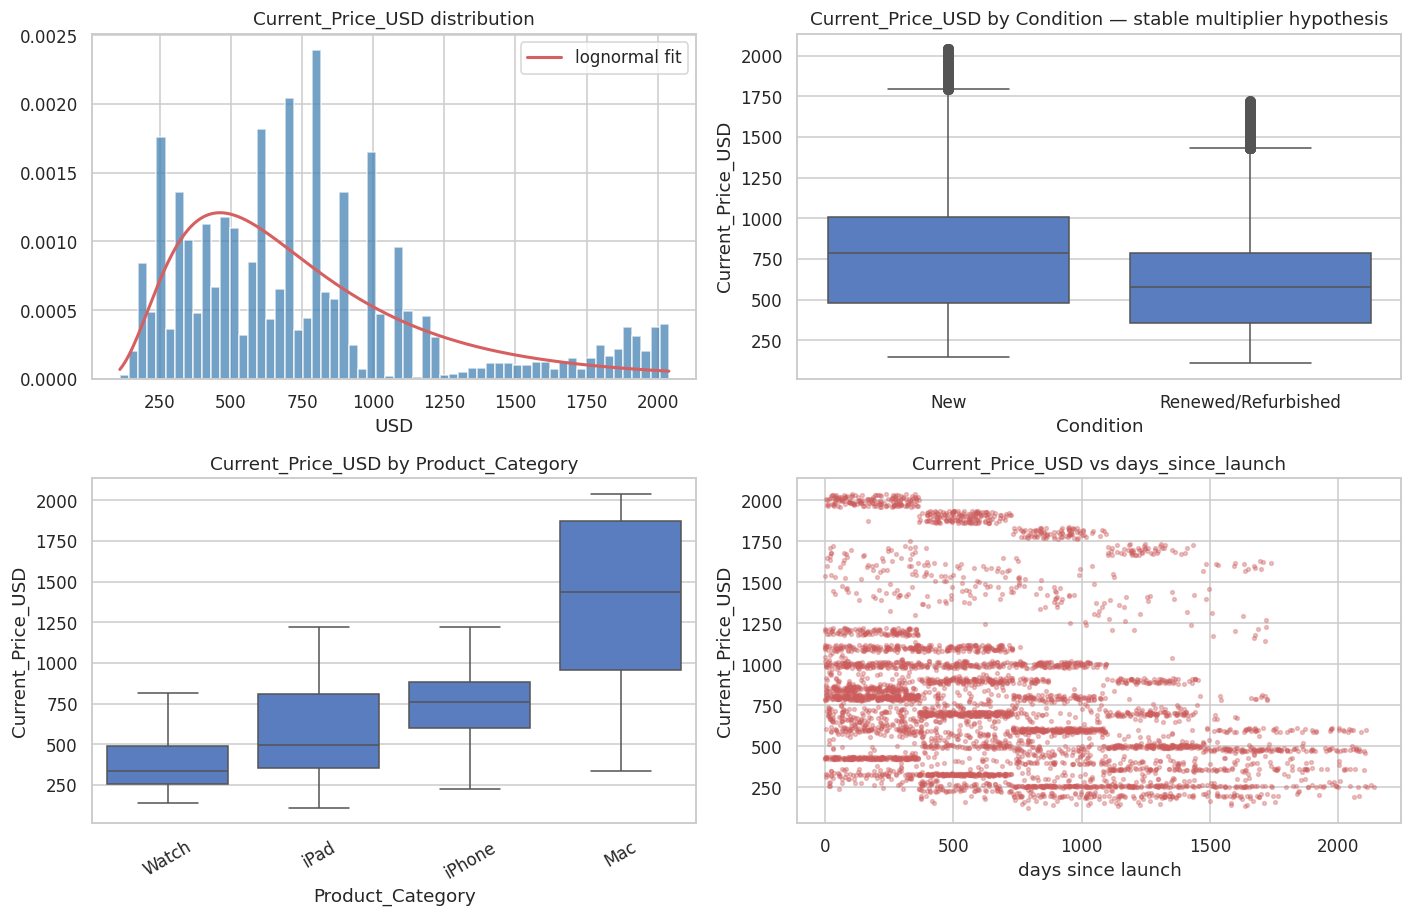

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

ax = axes[0, 0]
ax.hist(t, bins=60, density=True, alpha=.75, color='steelblue', edgecolor='white')
shape, loc, scale = stats.lognorm.fit(t, floc=0)
xs = np.linspace(t.min(), t.max(), 400)
ax.plot(xs, stats.lognorm.pdf(xs, shape, loc, scale), 'r-', lw=2, label='lognormal fit')
ax.set(title=f'{TARGET} distribution', xlabel='USD')
ax.legend()

sns.boxplot(data=df, x='Condition', y=TARGET, ax=axes[0, 1])
axes[0, 1].set_title(f'{TARGET} by Condition — stable multiplier hypothesis')

sns.boxplot(data=df, x='Product_Category', y=TARGET, ax=axes[1, 0])
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title(f'{TARGET} by Product_Category')

sample = df.sample(min(5000, len(df)), random_state=0)
axes[1, 1].scatter(sample['days_since_launch'], sample[TARGET], s=6, alpha=.35, color='indianred')
axes[1, 1].set(title=f'{TARGET} vs days_since_launch', xlabel='days since launch', ylabel=TARGET)

plt.tight_layout()
plt.show()

**Read-out:** raw price is strongly right-skewed (log-transform territory) — a lognormal fit tracks it reasonably well, though tree-based models handle this natively while linear models would benefit from a log transform. The Condition boxplot is the first check of the *stable multiplier* hypothesis: the Renewed/Refurbished distribution should sit a roughly constant amount below New across categories. The `days_since_launch` scatter gives a first, noisy look at depreciation, confounded here by category price levels — Section 5 isolates it per category.

## 4. Feature distributions, relationships to target, and cardinality assessment

In [9]:
NUM_FEATS = ['Launch_Price_USD', 'Rating', 'Reviews_Count', 'storage_gb', 'generation',
             'days_since_launch', 'month', 'is_sale_event']
num_summary = df[NUM_FEATS].describe().T
num_summary['skew'] = df[NUM_FEATS].skew()
num_summary['distribution_flag'] = np.where(num_summary['skew'].abs() > 1, 'skewed / heavy-tailed', 'ok')
num_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,distribution_flag
Launch_Price_USD,80000.0,963.96,470.09,329.0,599.0,799.0,1199.0,1999.0,1.03,skewed / heavy-tailed
Rating,80000.0,4.45,0.27,3.8,4.3,4.4,4.7,4.9,-0.30,ok
Reviews_Count,80000.0,2406.00,1973.63,10.0,896.0,1893.5,3383.0,11526.0,1.25,skewed / heavy-tailed
storage_gb,62135.0,223.17,146.37,64.0,128.0,128.0,256.0,512.0,0.97,ok
generation,72443.0,8.17,5.45,1.0,3.0,8.0,14.0,17.0,0.16,ok
days_since_launch,80000.0,685.65,493.94,0.0,280.0,590.0,1005.0,2142.0,0.70,ok
month,80000.0,6.40,3.46,1.0,3.0,6.0,10.0,12.0,0.07,ok
is_sale_event,80000.0,0.08,0.28,0.0,0.0,0.0,0.0,1.0,3.02,skewed / heavy-tailed


In [10]:
CAT_FEATS = ['Platform', 'Product_Category', 'Model_Name', 'Condition', 'Sale_Event', 'Stock_Status', 'variant_tier']
cat_summary = pd.DataFrame({
    'cardinality': {c: df[c].nunique() for c in CAT_FEATS},
    'top_5_categories': {c: dict(df[c].value_counts().head(5)) for c in CAT_FEATS},
})
cat_summary

,cardinality,top_5_categories
Platform,2,"{'Flipkart': 40043, 'Amazon': 39957}"
Product_Category,4,"{'iPhone': 28589, 'Mac': 18020, 'Watch': 17865, 'iPad': 15526}"
Model_Name,31,"{'iPhone 14 Pro 128GB': 2734, 'iPad Air (4th Gen) 64GB': 2677, 'iPad Pro 11-inch (M1) 128GB': 2661, 'iPhone 17 128GB..."
Condition,2,"{'New': 59985, 'Renewed/Refurbished': 20015}"
Sale_Event,5,"{'None': 73351, 'Black Friday': 2497, 'Big Billion Days': 1579, 'Great Indian Festival': 1504, 'Prime Day': 1069}"
Stock_Status,3,"{'In Stock': 55034, 'Out of Stock': 13475, 'Low Stock': 11491}"
variant_tier,5,"{'base': 30867, 'Pro': 25937, 'Air': 13009, 'Pro Max': 5150, 'Ultra': 5037}"


In [11]:
# Association with the target. Spearman for numerics; eta-squared for categoricals.
def eta_squared(frame, cat, target):
    grand = frame[target].mean()
    ss_between = frame.groupby(cat)[target].agg(['count', 'mean']).eval('count * (mean - @grand) ** 2').sum()
    ss_total = ((frame[target] - grand) ** 2).sum()
    return ss_between / ss_total

num_assoc = pd.DataFrame({
    f'spearman_vs_{TARGET}': df[NUM_FEATS + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET),
}).sort_values(f'spearman_vs_{TARGET}', key=lambda s: s.abs(), ascending=False)

cat_assoc = pd.DataFrame({
    f'eta2_vs_{TARGET}': {c: eta_squared(df, c, TARGET) for c in CAT_FEATS},
}).sort_values(f'eta2_vs_{TARGET}', ascending=False)

print("Numeric features (Spearman):")
print(num_assoc.round(3).to_string())
print("\nCategorical features (eta-squared: share of target variance explained):")
print(cat_assoc.round(3).to_string())

Numeric features (Spearman):
                   spearman_vs_Current_Price_USD
Launch_Price_USD                           0.920
storage_gb                                 0.864
days_since_launch                         -0.357
Reviews_Count                             -0.316
generation                                -0.198
Rating                                     0.113
is_sale_event                             -0.094
month                                     -0.025

Categorical features (eta-squared: share of target variance explained):
                  eta2_vs_Current_Price_USD
Model_Name                            0.911
Product_Category                      0.576
variant_tier                          0.452
Condition                             0.031
Stock_Status                          0.014
Sale_Event                            0.008
Platform                              0.000


### Cardinality assessment: `Product_Category` vs `Model_Name` vs parsed attributes

The concern, stated explicitly:

- **`Product_Category` alone is too coarse** — different iPhone models carry different `Launch_Price_USD` (storage options, Pro vs Pro Max), so category-level encoding blurs real price positioning.
- **`Model_Name` is precise but not deployable** — the final model must be **`Model_Name`-agnostic**: it must score models that don't exist in the training data (e.g., *iPhone 19 128GB*). A one-hot or target-encoded `Model_Name` has no representation for an unseen name. It's also high-cardinality (one level per model) and, since launch price is constant within a model, partially duplicates `Launch_Price_USD`.
- **Resolution — decompose `Model_Name` into generalizable attributes:** `Product_Category` + `variant_tier` + `storage_gb` + `generation`. An unseen *iPhone 19 128GB* maps to (iPhone, base, 128, 19) — every component was seen in training. The cell below quantifies how much of `Model_Name`'s explanatory power this decomposition recovers.
- **A cheaper alternative — `Product_Category` + `Launch_Price_USD`:** since `Launch_Price_USD` is already a numeric feature in the model, pairing it with `Product_Category` gives a sub-category grouping with no parsing heuristics at all. Checked below alongside the other three to see how much of `Model_Name`'s signal this simpler combination recovers.

In [12]:
# How much of Model_Name's signal do the agnostic attributes recover?
df['_agnostic_combo'] = (df['Product_Category'] + '|' + df['variant_tier'] + '|'
                         + df['storage_gb'].fillna(-1).astype(int).astype(str) + '|'
                         + df['generation'].fillna(-1).astype(int).astype(str))
df['_cat_price_combo'] = df['Product_Category'] + '|' + df['Launch_Price_USD'].astype(str)

comparison = pd.DataFrame({
    'cardinality': {
        'Product_Category': df['Product_Category'].nunique(),
        'Model_Name': df['Model_Name'].nunique(),
        'agnostic combo (cat+tier+storage+gen)': df['_agnostic_combo'].nunique(),
        'Product_Category + Launch_Price_USD': df['_cat_price_combo'].nunique(),
    },
    f'eta2_vs_{TARGET}': {
        'Product_Category': eta_squared(df, 'Product_Category', TARGET),
        'Model_Name': eta_squared(df, 'Model_Name', TARGET),
        'agnostic combo (cat+tier+storage+gen)': eta_squared(df, '_agnostic_combo', TARGET),
        'Product_Category + Launch_Price_USD': eta_squared(df, '_cat_price_combo', TARGET),
    },
})
print(comparison.round(3).to_string())

recovered = comparison.loc['agnostic combo (cat+tier+storage+gen)', f'eta2_vs_{TARGET}'] / \
            max(comparison.loc['Model_Name', f'eta2_vs_{TARGET}'], 1e-9) * 100
recovered_price = comparison.loc['Product_Category + Launch_Price_USD', f'eta2_vs_{TARGET}'] / \
            max(comparison.loc['Model_Name', f'eta2_vs_{TARGET}'], 1e-9) * 100
print(f"\nAgnostic attributes recover {recovered:.1f}% of Model_Name's explanatory power on {TARGET}.")
print("If close to 100%, drop Model_Name from the feature set with little cost — and gain")
print("the ability to score unseen models. Note the combo's cardinality vs Model_Name's:")
print("a gap means some models collapse to the same attribute tuple (usually harmless).")
print(f"\nProduct_Category + Launch_Price_USD recovers {recovered_price:.1f}% of Model_Name's explanatory")
print("power with no parsing heuristics at all — compare its cardinality/eta2 tradeoff against the")
print("agnostic combo above. It cannot, however, distinguish an unseen model's storage/tier/generation")
print("if a new model reuses an existing category+launch-price pair (e.g. a same-priced refresh).")
df = df.drop(columns=['_agnostic_combo', '_cat_price_combo'])

                                       cardinality  eta2_vs_Current_Price_USD
Product_Category                                 4                      0.576
Model_Name                                      31                      0.911
agnostic combo (cat+tier+storage+gen)           30                      0.910
Product_Category + Launch_Price_USD             16                      0.905

Agnostic attributes recover 100.0% of Model_Name's explanatory power on Current_Price_USD.
If close to 100%, drop Model_Name from the feature set with little cost — and gain
the ability to score unseen models. Note the combo's cardinality vs Model_Name's:
a gap means some models collapse to the same attribute tuple (usually harmless).

Product_Category + Launch_Price_USD recovers 99.4% of Model_Name's explanatory
power with no parsing heuristics at all — compare its cardinality/eta2 tradeoff against the
agnostic combo above. It cannot, however, distinguish an unseen model's storage/tier/generation
if a

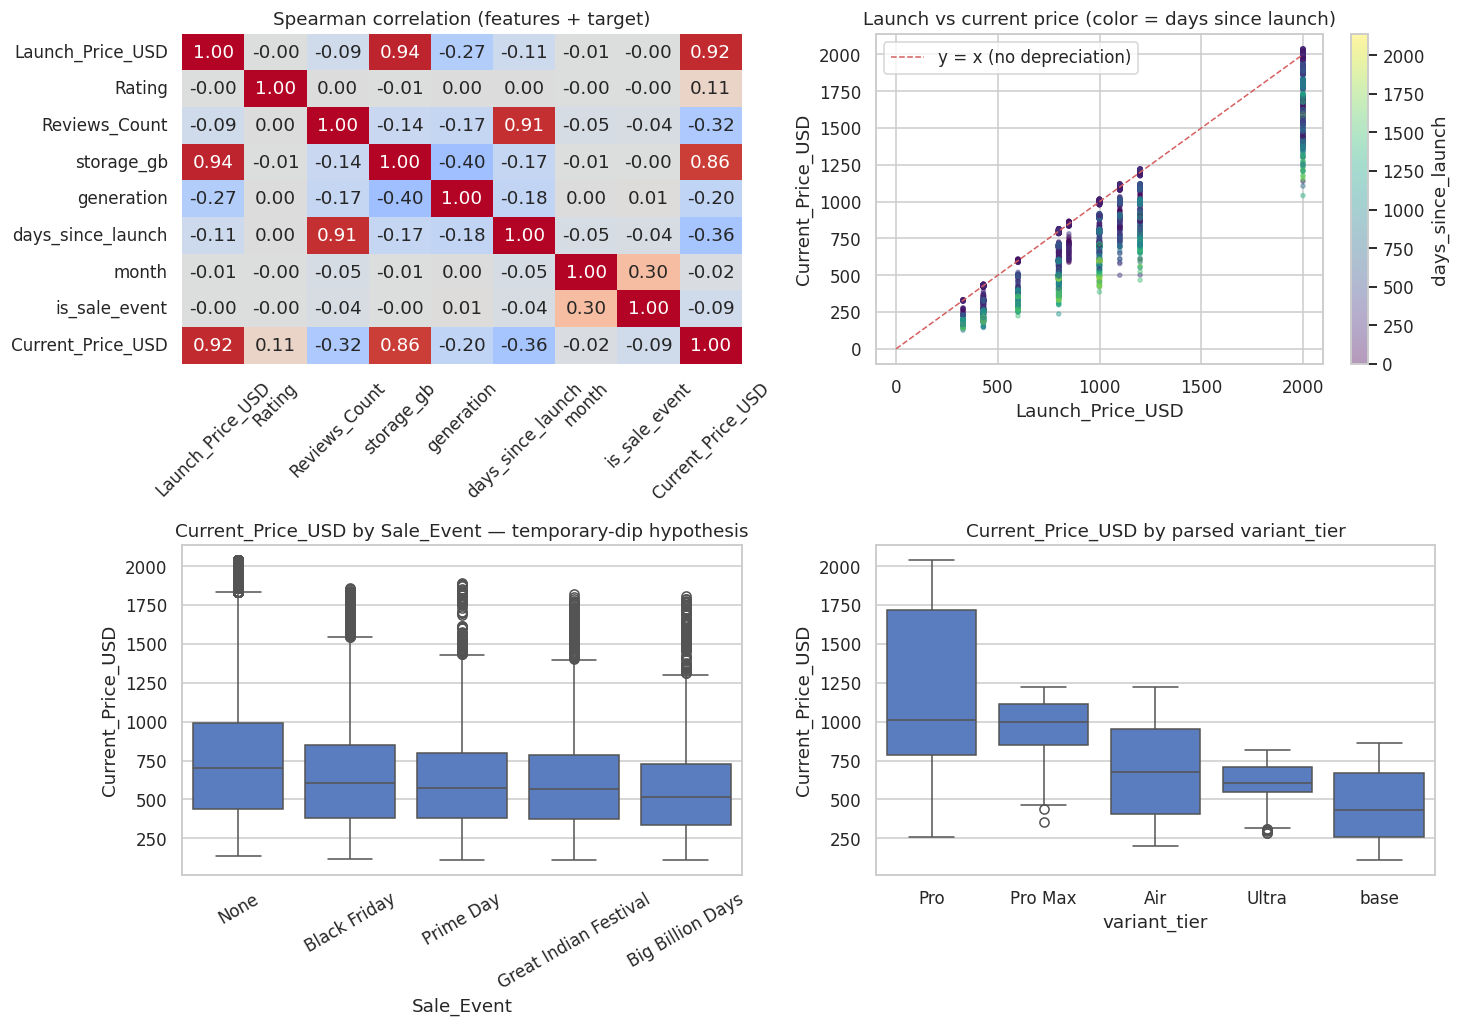

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))

corr_cols = NUM_FEATS + [TARGET]
sns.heatmap(df[corr_cols].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0, 0], cbar=False,
            xticklabels=corr_cols, yticklabels=corr_cols)
axes[0, 0].set_title('Spearman correlation (features + target)')
axes[0, 0].tick_params(axis='x', rotation=45)

sample = df.sample(min(5000, len(df)), random_state=0)
sc = axes[0, 1].scatter(sample['Launch_Price_USD'], sample[TARGET],
                        c=sample['days_since_launch'], cmap='viridis', s=7, alpha=.4)
axes[0, 1].plot([0, sample['Launch_Price_USD'].max()],
                [0, sample['Launch_Price_USD'].max()], 'r--', lw=1, label='y = x (no depreciation)')
axes[0, 1].set(xlabel='Launch_Price_USD', ylabel=TARGET, title='Launch vs current price (color = days since launch)')
axes[0, 1].legend()
plt.colorbar(sc, ax=axes[0, 1], label='days_since_launch')

order = df.groupby('Sale_Event')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Sale_Event', y=TARGET, order=order, ax=axes[1, 0])
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title(f'{TARGET} by Sale_Event — temporary-dip hypothesis')

sns.boxplot(data=df, x='variant_tier', y=TARGET, ax=axes[1, 1],
            order=df.groupby('variant_tier')[TARGET].median().sort_values(ascending=False).index)
axes[1, 1].set_title(f'{TARGET} by parsed variant_tier')

plt.tight_layout()
plt.show()

**Read-out for feature selection:** `Launch_Price_USD` dominates `Current_Price_USD` by construction — it sets the scale each product depreciates from — so it stays in the feature set as the anchor while `days_since_launch`, `Condition`, and `Sale_Event` explain the deviation from it. Check the association tables above for the relative ranking of each feature against the raw-price target.

## 5. Temporal patterns — depreciation hypothesis test & the `Reviews_Count` check

### Hypothesis test: does price systematically decrease with time since launch? (ANOVA)

- **H0:** There is no relationship between time since launch and Apple product price; price does not systematically decrease over time.
- **H1:** Apple product price decreases as time since launch increases, with additional downward drops occurring around new product release dates.

**Time-bin ANOVA (per category):** `days_since_launch` is cut into deciles within each `Product_Category` (binning per category avoids confounding the test with cross-category price-level differences), and a one-way ANOVA tests whether mean `Current_Price_USD` differs across bins. Since ANOVA alone tests *any* difference and not direction, Spearman `rho` between `days_since_launch` and price is reported alongside it to confirm the sign of the effect.

In [14]:
N_BINS = 8
ALPHA = 0.05
df['launch_age_bin'] = df.groupby('Product_Category')['days_since_launch'] \
    .transform(lambda s: pd.qcut(s, q=N_BINS, duplicates='drop'))

# --- One-way ANOVA on price across days_since_launch bins, per category ---
rows = []
for cat, g in df.groupby('Product_Category'):
    groups = [grp[TARGET].values for _, grp in g.groupby('launch_age_bin', observed=True)]
    f_stat, p_val = stats.f_oneway(*groups)
    rho, _ = stats.spearmanr(g['days_since_launch'], g[TARGET])
    rows.append({'Product_Category': cat, 'F': f_stat, 'p_value': p_val, 'spearman_rho': rho})
test1 = pd.DataFrame(rows).set_index('Product_Category')

print("Price across days_since_launch bins (per category):")
print(test1.round(4).to_string())

df = df.drop(columns=['launch_age_bin'])

# --- Verdict ---
test1_reject = (test1['p_value'] < ALPHA).all()
test1_decreasing = (test1['spearman_rho'] < 0).all()
print(f"\nVERDICT:")
if test1_reject and test1_decreasing:
    print(f"- Rejects H0 in every category (all p < {ALPHA}), and Spearman rho is negative")
    print(f"  in every category -> price decreases systematically with days_since_launch.")
    print(f"  Supports H1's main clause: reject H0.")
else:
    print(f"- {'Rejects' if test1_reject else 'Fails to reject'} H0 across categories; ")
    print(f"  direction is {'consistently negative' if test1_decreasing else 'not consistent across categories'} — see test1 table.")

Price across days_since_launch bins (per category):
                          F  p_value  spearman_rho
Product_Category                                  
Mac                444.1466      0.0       -0.4123
Watch              601.2016      0.0       -0.5206
iPad               747.3696      0.0       -0.5028
iPhone            1729.5862      0.0       -0.5138

VERDICT:
- Rejects H0 in every category (all p < 0.05), and Spearman rho is negative
  in every category -> price decreases systematically with days_since_launch.
  Supports H1's main clause: reject H0.


### `Reviews_Count` — is it cumulative? (synthetic-data check)

This dataset is synthetically generated, so properties a real marketplace would guarantee must be verified, not assumed. If `Reviews_Count` were real, the same `Model_Name` should accumulate reviews monotonically over time. The check below computes, per model, (a) the Spearman correlation between listing date and `Reviews_Count`, and (b) the fraction of consecutive (date-sorted) observations where the count does not decrease.

                                  n_obs  spearman_time  pct_non_decreasing
Model_Name                                                                
Apple Watch Series 6 (44mm)        2572          0.867               0.504
Apple Watch Series 7 (45mm)        2600          0.868               0.506
Apple Watch Series 8 (45mm)        2606          0.865               0.502
Apple Watch Series 9 (45mm)        2530          0.864               0.499
Apple Watch Series X (45mm)        2520          0.856               0.498
Apple Watch Ultra                  2544          0.862               0.505
Apple Watch Ultra 2                2493          0.855               0.506
MacBook Air M1 256GB               2550          0.851               0.505
MacBook Air M2 256GB               2610          0.851               0.507
MacBook Air M3 256GB               2589          0.847               0.491
MacBook Pro 14-inch M1 Pro 512GB   2545          0.858               0.499
MacBook Pro 14-inch M2 Pr

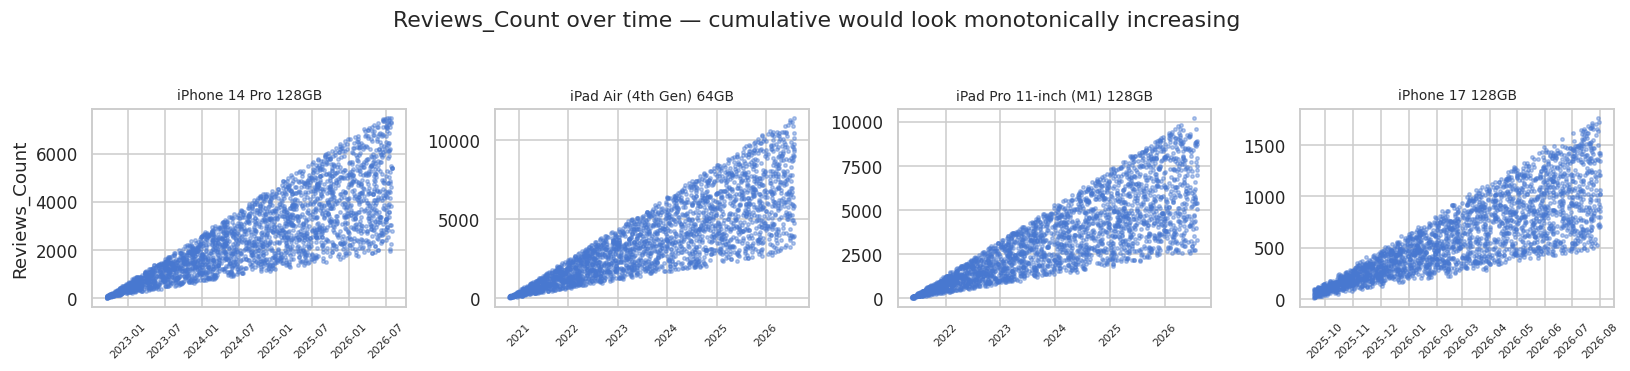

In [15]:
srt = df.sort_values('Date')
per_model = srt.groupby('Model_Name').agg(
    n_obs=('Reviews_Count', 'size'),
    spearman_time=('Reviews_Count', lambda s: s.reset_index(drop=True).corr(
        pd.Series(np.arange(len(s))), method='spearman')),
)
per_model['pct_non_decreasing'] = srt.groupby('Model_Name')['Reviews_Count'] \
    .apply(lambda s: s.diff().dropna().ge(0).mean())

print(per_model.round(3).to_string())
med_rho = per_model['spearman_time'].median()
med_mono = per_model['pct_non_decreasing'].median()
print(f"\nMedian Spearman(time, reviews) across models: {med_rho:.3f}")
print(f"Median share of non-decreasing consecutive steps: {med_mono:.3f}")

if med_rho > 0.8 and med_mono > 0.9:
    print("\nVERDICT: Reviews_Count behaves cumulatively -> it is largely a proxy for product age.")
    print("Expect strong collinearity with days_since_launch; keep only one of the two.")
else:
    print("\nVERDICT: Reviews_Count is NOT cumulative — counts fluctuate per listing snapshot.")
    print("The synthetic generator drew them (near-)randomly. It is at best a noisy popularity")
    print("proxy and at worst pure noise: expect weak association with the target (Section 4")
    print("table) and treat it as a drop candidate.")

# Visual: reviews over time for the 4 most-observed models
top4 = df['Model_Name'].value_counts().head(4).index
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=False)
for ax, m in zip(axes, top4):
    g = srt[srt['Model_Name'] == m]
    ax.scatter(g['Date'], g['Reviews_Count'], s=5, alpha=.4)
    ax.set_title(m, fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
axes[0].set_ylabel('Reviews_Count')
fig.suptitle('Reviews_Count over time — cumulative would look monotonically increasing', y=1.05)
plt.tight_layout()
plt.show()

## 6. Data quality flags and feature-selection summary

In [16]:
flags = []

# Leakage columns: already dropped at load (Section 0) — recorded here for completeness
for c in ['Current_Price_INR (target in INR)', 'Discount_Pct (derived from target)',
          'Launch_Price_INR (redundant with USD)']:
    flags.append((f'Leakage/redundancy: {c.split(" (")[0]}', c.split('(')[1].rstrip(')'),
                  'DROPPED at load — see Section 0'))

# Duplicates
exact = df.duplicated().sum()
flags.append(('Exact duplicate rows', f"{exact:,}",
              'drop before training' if exact else 'none — OK'))
key = df.duplicated(subset=['Date', 'Platform', 'Model_Name', 'Condition']).sum()
flags.append(('Duplicate (Date, Platform, Model, Condition) keys', f"{key:,}",
              'repeated observations per key — use time-based or grouped CV splits'))

# Highly correlated feature pairs (|rho| > 0.9)
feat_corr = df[NUM_FEATS].corr(method='spearman').abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
found = False
for a in upper.columns:
    for b, v in upper[a].dropna().items():
        if v > 0.9:
            flags.append((f'Correlated pair: {b} ~ {a}', f"|rho| = {v:.3f}", 'keep only one'))
            found = True
if not found:
    flags.append(('Highly correlated feature pairs (|rho| > 0.9)', 'none found', 'OK'))

# Near-zero variance
for col in df.columns:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if df[col].nunique(dropna=False) <= 1 or top_share > 0.99:
        flags.append((f'Near-zero variance: {col}', f"top value covers {top_share*100:.1f}%", 'no signal — drop'))

# Transformation needs (continuous columns only)
for col in ['Launch_Price_USD', 'Reviews_Count', 'storage_gb', 'days_since_launch', TARGET]:
    sk = df[col].skew()
    if abs(sk) > 1:
        flags.append((f'Skewed column: {col}', f"skew = {sk:.2f}",
                      'consider log / rank transform for linear models'))

flags_df = pd.DataFrame(flags, columns=['Issue', 'Evidence', 'Implication'])
flags_df

,Issue,Evidence,Implication
0,Leakage/redundancy: Current_Price_INR,target in INR,DROPPED at load — see Section 0
1,Leakage/redundancy: Discount_Pct,derived from target,DROPPED at load — see Section 0
2,Leakage/redundancy: Launch_Price_INR,redundant with USD,DROPPED at load — see Section 0
3,Exact duplicate rows,0,none — OK
4,"Duplicate (Date, Platform, Model, Condition) keys","21,389",repeated observations per key — use time-based or grouped CV splits
5,Correlated pair: Launch_Price_USD ~ storage_gb,|rho| = 0.944,keep only one
6,Correlated pair: Reviews_Count ~ days_since_launch,|rho| = 0.908,keep only one
7,Skewed column: Launch_Price_USD,skew = 1.03,consider log / rank transform for linear models
8,Skewed column: Reviews_Count,skew = 1.25,consider log / rank transform for linear models
9,Skewed column: Current_Price_USD,skew = 1.11,consider log / rank transform for linear models


### Feature-selection summary for price modeling

**Target:** `Current_Price_USD` — predicted directly as the suggested fair-market listing price.

**Dropped at load (leakage / redundancy):** `Current_Price_INR`, `Discount_Pct`, `Launch_Price_INR` — see Section 0 note.

**Launch date:** `researched_launch_date` (manually sourced per `Model_Name`) matches `proxy_launch_date` (first listing date) closely for every model in this dataset — max 1-day gap, see the Section 1 comparison — so `days_since_launch` is a reliable depreciation clock either way.

**Model_Name-agnostic feature set (deployable on any product a seller lists, including unseen models like iPhone 19 128GB):**

| Feature | Role |
|---|---|
| `Launch_Price_USD` | anchor — sets the scale `Current_Price_USD` depreciates from |
| `days_since_launch` | depreciation clock — core hypothesis driver |
| `Product_Category` | category-specific decay curves |
| `variant_tier`, `storage_gb`, `generation` | parsed from Model_Name — recover its signal without its cardinality |
| `Condition` | stable multiplier hypothesis |
| `Sale_Event` / `is_sale_event`, `month` | temporary festival dips, seasonality |
| `Platform`, `Stock_Status` | marketplace effects (check Section 4 tables for actual signal) |

**Do not one-hot `Model_Name` itself** — unseen models would have no representation, and within-model constancy of launch price makes it partly redundant.

**`Rating` / `Reviews_Count`:** keep only if Section 4 shows real signal; see the Section 5 cumulative-nature verdict — if non-cumulative (synthetic noise), drop `Reviews_Count`.

**Validation:** time-based splits (train early, test late) — this both respects the repeated-observations structure and directly measures what the feature needs in production: suggesting prices for future dates and newly launched models.

## 7. Train/test split — shared baseline for predictive modeling

**Cutoff:** train on rows before **2025-08-01**, test on rows from that date onward.

**Why a time-based cutoff instead of a random split:**

- **Prevents leakage.** The real task is forecasting a fair listing price *forward* in time — a seller lists a product today and needs today's price, with no access to tomorrow's data. A random split would scatter observations of the same `Model_Name` across train and test at nearby (or even later) dates, letting a model implicitly see future price levels for a model it's being evaluated on. Section 6 already flagged 21,389 duplicate `(Date, Platform, Model_Name, Condition)` keys — a random split would routinely place near-identical repeated observations on both sides. A chronological cutoff eliminates this by construction: every train row strictly precedes every test row.
- **Preserves a workable size ratio.** The cutoff below lands close to a 68/32 train/test split — enough test volume (~26k rows) to evaluate reliably, while keeping ~5 years of history in train so every model's full depreciation curve (early listing through late-life pricing) is represented.

**Baseline artifact:** the split below is saved to `apple_pricing_train.csv` / `apple_pricing_test.csv` (same directory as the source data), built on top of every column engineered in Sections 0–1. 

In [17]:
CUTOFF = pd.Timestamp('2025-08-01')

df = df.sort_values('Date').reset_index(drop=True)
train = df[df['Date'] < CUTOFF].copy()
test = df[df['Date'] >= CUTOFF].copy()

assert train['Date'].max() < test['Date'].min(), "Train/test overlap in time — split is not chronological"
assert len(train) + len(test) == len(df), "Split does not cover all rows"

n = len(df)
print(f"Train: {len(train):>7,} rows ({len(train)/n*100:.1f}%)  {train['Date'].min():%Y-%m-%d} to {train['Date'].max():%Y-%m-%d}")
print(f"Test:  {len(test):>7,} rows ({len(test)/n*100:.1f}%)  {test['Date'].min():%Y-%m-%d} to {test['Date'].max():%Y-%m-%d}")

train.to_csv('apple_pricing_train.csv', index=False)
test.to_csv('apple_pricing_test.csv', index=False)
print(f"\nSaved: apple_pricing_train.csv ({len(train):,} rows), apple_pricing_test.csv ({len(test):,} rows)")
print("Load these two files directly for modeling — every teammate then trains/evaluates on the")
print("exact same rows, with the exact same engineered features from Sections 0-1.")

Train:  54,099 rows (67.6%)  2020-09-19 to 2025-07-31
Test:   25,901 rows (32.4%)  2025-08-01 to 2026-07-31



Saved: apple_pricing_train.csv (54,099 rows), apple_pricing_test.csv (25,901 rows)
Load these two files directly for modeling — every teammate then trains/evaluates on the
exact same rows, with the exact same engineered features from Sections 0-1.


# 8. Leakage-Safe Continuous Feature Engineering

This corrected workflow follows one rule:

> **Every feature for a listing must use only information available before that listing date.**

The adapted product-level RFM variables are:

- **Recency — `days_since_launch`:** product age on the listing date.
- **Frequency — `Previous_Listings`:** the number of listings for that model on strictly earlier dates.
- **Monetary — `Launch_Price_USD`:** the product's original launch price.

Unlike the earlier total `Listing_Frequency`, `Previous_Listings` does not include later observations. Listings on the same date receive the same count because the ordering of listings within a day is unknown.

In [18]:
# Ensure chronological order before creating any history-dependent feature.
df = df.sort_values(['Date', 'Model_Name']).reset_index(drop=True)

# Count listings per model and date, then shift the cumulative total by one date.
# This means a listing can see all prior dates, but not other listings from its own date
# or any future date.
daily_model_counts = (
    df.groupby(['Model_Name', 'Date'])
      .size()
      .rename('Listings_On_Date')
      .reset_index()
      .sort_values(['Model_Name', 'Date'])
)

daily_model_counts['Previous_Listings'] = (
    daily_model_counts.groupby('Model_Name')['Listings_On_Date']
                      .cumsum()
                      .groupby(daily_model_counts['Model_Name'])
                      .shift(1)
                      .fillna(0)
                      .astype(int)
)

df = df.merge(
    daily_model_counts[['Model_Name', 'Date', 'Previous_Listings']],
    on=['Model_Name', 'Date'],
    how='left',
    validate='many_to_one'
)

RFM_CONTINUOUS_FEATURES = [
    'days_since_launch',
    'Previous_Listings',
    'Launch_Price_USD'
]

# Causal validation: counts can never decrease within a model.
assert (
    df.sort_values(['Model_Name', 'Date'])
      .groupby('Model_Name')['Previous_Listings']
      .diff()
      .fillna(0) >= 0
).all()

display(df[['Date', 'Model_Name', 'Previous_Listings']].head(12))
display(df[RFM_CONTINUOUS_FEATURES].describe().round(2))

,Date,Model_Name,Previous_Listings
0,2020-09-19,Apple Watch Series 6 (44mm),0
1,2020-09-20,Apple Watch Series 6 (44mm),1
2,2020-09-23,Apple Watch Series 6 (44mm),2
3,2020-09-23,Apple Watch Series 6 (44mm),2
4,2020-09-24,Apple Watch Series 6 (44mm),4
5,2020-09-26,Apple Watch Series 6 (44mm),5
6,2020-09-27,Apple Watch Series 6 (44mm),6
7,2020-09-29,Apple Watch Series 6 (44mm),7
8,2020-10-01,Apple Watch Series 6 (44mm),8
9,2020-10-01,Apple Watch Series 6 (44mm),8


,days_since_launch,Previous_Listings,Launch_Price_USD
count,80000.00,80000.00,80000.00
mean,685.65,1289.27,963.96
std,493.94,746.02,470.09
min,0.00,0.00,329.00
25%,280.00,644.00,599.00
50%,590.00,1289.00,799.00
75%,1005.00,1934.00,1199.00
max,2142.00,2732.00,1999.00


## Leakage guards and chronological split

The cutoff remains **August 1, 2025**. Target-derived variables are removed before modeling. The split occurs before fitting encoders or calculating any training-dependent transformations.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

CUTOFF = pd.Timestamp('2025-08-01')
TARGET = 'Current_Price_USD'
TARGET_DERIVED_FEATURES = [
    'Price_Retention', 'Depreciation_Index',
    'Discount_Pct', 'Current_Price_INR'
]

df.drop(columns=TARGET_DERIVED_FEATURES, errors='ignore', inplace=True)
df = df.dropna(subset=['Date', TARGET]).sort_values('Date').reset_index(drop=True)

train_raw = df[df['Date'] < CUTOFF].copy()
test_raw = df[df['Date'] >= CUTOFF].copy()

assert not train_raw.empty and not test_raw.empty
assert train_raw['Date'].max() < test_raw['Date'].min()

print(f"Train: {len(train_raw):,} rows | {train_raw['Date'].min().date()} to {train_raw['Date'].max().date()}")
print(f"Test:  {len(test_raw):,} rows | {test_raw['Date'].min().date()} to {test_raw['Date'].max().date()}")
print(f"Unseen test models: {sorted(set(test_raw['Model_Name']) - set(train_raw['Model_Name']))}")

Train: 54,099 rows | 2020-09-19 to 2025-07-31
Test:  25,901 rows | 2025-08-01 to 2026-07-31
Unseen test models: ['iPhone 17 128GB']


## Model preparation

Categorical encoding is fit on the training data only, and test columns are aligned to the training design matrix. `Model_Name` is excluded so the model is evaluated using transferable product attributes rather than memorizing specific products.

The feature matrix combines:

- **Continuous / RFM variables:** `days_since_launch` (recency), `Previous_Listings` (frequency), `Launch_Price_USD` (monetary), plus `storage_gb`, `generation`, `month`, `is_sale_event`
- **One-hot categoricals:** `Platform`, `Product_Category`, `Condition`, `Sale_Event`, `Stock_Status`, `variant_tier`

Excluded in addition to `Model_Name`: `Rating` / `Reviews_Count` (Section 5 synthetic-data verdict) and the `_agnostic_combo` / `_cat_price_combo` helper columns from Section 4 (one-hot encoding them would re-introduce model identity and break the unseen-model evaluation).

In [20]:
MODEL_DROP_COLS = [
    TARGET, 'Date', 'Model_Name',
    'Launch_Date', 'researched_launch_date', 'proxy_launch_date',
    'Rating', 'Reviews_Count',           # Section 5 verdict: synthetic, non-cumulative
    '_agnostic_combo', '_cat_price_combo',  # Section 4 helpers: encode model identity
]


def encode_train_test(train_frame, test_frame):
    X_train = train_frame.drop(columns=MODEL_DROP_COLS, errors='ignore').copy()
    X_test = test_frame.drop(columns=MODEL_DROP_COLS, errors='ignore').copy()
    y_train = train_frame[TARGET].copy()
    y_test = test_frame[TARGET].copy()

    # Remove any remaining datetime columns.
    date_cols = X_train.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns
    X_train.drop(columns=date_cols, inplace=True, errors='ignore')
    X_test.drop(columns=date_cols, inplace=True, errors='ignore')

    # Encode categories using the training design matrix, then align test columns.
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=np.int8)
    X_test = pd.get_dummies(X_test, drop_first=True, dtype=np.int8)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Learn missing-value replacements from training only.
    medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(medians).fillna(0)
    X_test = X_test.fillna(medians).fillna(0)

    assert list(X_train.columns) == list(X_test.columns)
    assert not X_train.select_dtypes(exclude=np.number).columns.tolist()
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = encode_train_test(train_raw, test_raw)
print('Training matrix:', X_train.shape)
print('Test matrix:    ', X_test.shape)


Training matrix: (54099, 22)
Test matrix:     (25901, 22)


## Random Forest evaluation

The table reports **train and test RMSE, MAE, and R²**, plus the train/test gaps.

- A positive RMSE or MAE gap means test error is higher than training error.
- A positive R² gap means training R² is higher than test R².
- Very large gaps indicate possible overfitting.

In [21]:
def fit_and_evaluate_rf(X_train, X_test, y_train, y_test, label):
    model = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results = {
        'Model': label,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'RMSE Gap': test_rmse - train_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'MAE Gap': test_mae - train_mae,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'R² Gap': train_r2 - test_r2,
    }

    importance = (
        pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})
          .sort_values('Importance', ascending=False)
          .reset_index(drop=True)
    )
    return model, results, importance, train_pred, test_pred

rf_model, model_results, feature_importance, train_predictions, test_predictions = fit_and_evaluate_rf(
    X_train, X_test, y_train, y_test, 'Random Forest — Continuous Features'
)

results_table = pd.DataFrame([model_results])
display(results_table.round(4))


,Model,Train RMSE,Test RMSE,RMSE Gap,Train MAE,Test MAE,MAE Gap,Train R²,Test R²,R² Gap
0,Random Forest — Continuous Features,16.8041,37.607,20.8029,10.0616,23.3323,13.2706,0.9987,0.9932,0.0054


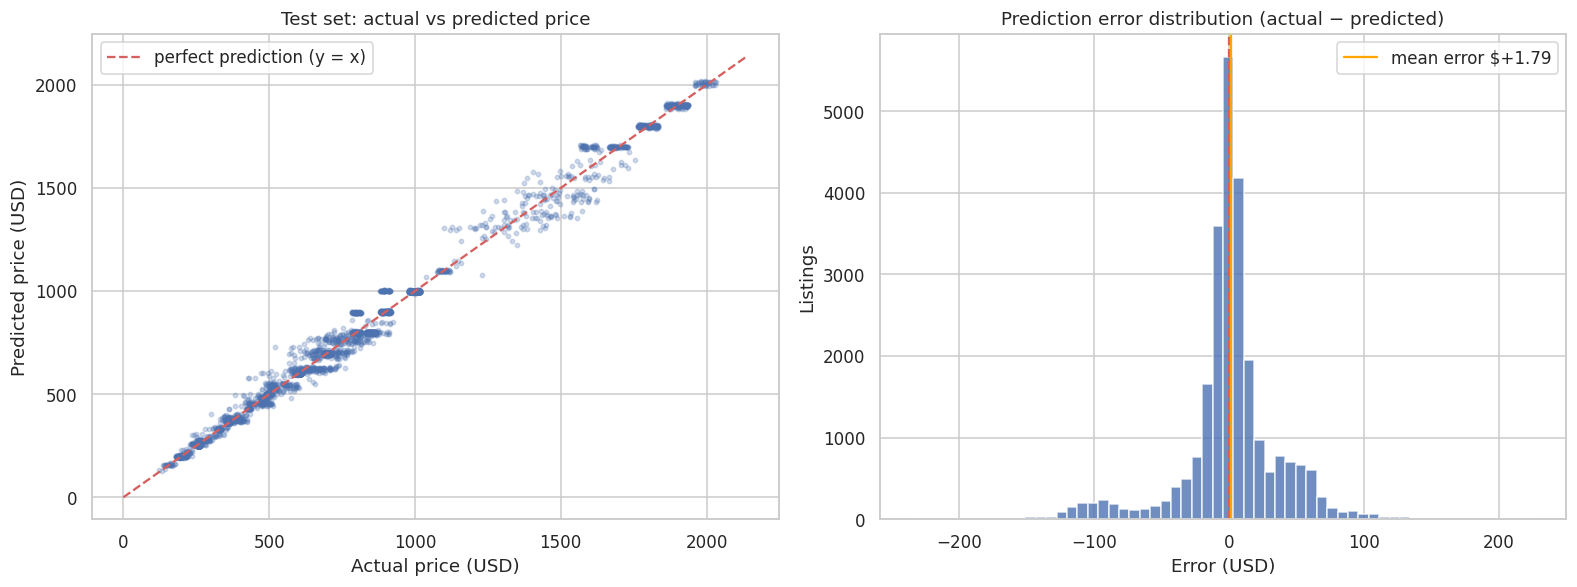

Predictions within $10 of actual: 47.4%  |  within $25: 71.1%  |  within $50: 84.8%


In [22]:
# Predicted vs actual on the test set, and the prediction errors
residuals = y_test.values - np.asarray(test_predictions)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))

# Left: actual vs predicted
idx = np.random.RandomState(42).choice(len(y_test), min(4000, len(y_test)), replace=False)
axes[0].scatter(y_test.values[idx], np.asarray(test_predictions)[idx], s=8, alpha=.25, color='#4c72b0')
lims = [0, float(y_test.max()) * 1.05]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='perfect prediction (y = x)')
axes[0].set(title='Test set: actual vs predicted price', xlabel='Actual price (USD)', ylabel='Predicted price (USD)')
axes[0].legend()

# Right: distribution of the differences (actual - predicted)
axes[1].hist(residuals, bins=60, color='#4c72b0', alpha=.8, edgecolor='white')
axes[1].axvline(0, color='r', ls='--', lw=1.5)
axes[1].axvline(residuals.mean(), color='orange', lw=1.5, label=f'mean error ${residuals.mean():+.2f}')
axes[1].set(title='Prediction error distribution (actual − predicted)', xlabel='Error (USD)', ylabel='Listings')
axes[1].legend()

plt.tight_layout()
plt.show()

within = [(np.abs(residuals) <= t).mean() * 100 for t in (10, 25, 50)]
print(f'Predictions within $10 of actual: {within[0]:.1f}%  |  within $25: {within[1]:.1f}%  |  within $50: {within[2]:.1f}%')

## Unseen-product evaluation — iPhone 17

The test below isolates products whose `Model_Name` never appeared in training. With this cutoff, that subset should be **iPhone 17 128GB**. Because `Model_Name` is excluded from the predictors, the model must generalize from attributes such as category, launch price, storage, condition, age, and prior marketplace activity.

In [ ]:
unseen_mask = ~test_raw['Model_Name'].isin(train_raw['Model_Name'])
unseen_models = sorted(test_raw.loc[unseen_mask, 'Model_Name'].unique())
print('Unseen models:', unseen_models)
print('Unseen rows:', int(unseen_mask.sum()))


def subset_metrics(y_true, predictions, mask, label):
    y_sub = y_true.loc[mask]
    pred_sub = np.asarray(predictions)[mask.to_numpy()]
    return {
        'Model': label,
        'Subset': 'Unseen product(s)',
        'Rows': len(y_sub),
        'RMSE': np.sqrt(mean_squared_error(y_sub, pred_sub)),
        'MAE': mean_absolute_error(y_sub, pred_sub),
        'R²': r2_score(y_sub, pred_sub) if len(y_sub) > 1 else np.nan
    }

unseen_results = pd.DataFrame([
    subset_metrics(
        y_test,
        test_predictions,
        unseen_mask,
        'Random Forest — Continuous Features'
    )
])
display(unseen_results.round(4))

# Confirm that the unseen subset is the iPhone 17.
iphone17_mask = test_raw['Model_Name'].str.contains('iPhone 17', case=False, na=False)
assert iphone17_mask.equals(unseen_mask), (
    'The unseen subset contains models other than iPhone 17, or iPhone 17 is not fully unseen.'
)

iphone17_preview = test_raw.loc[iphone17_mask, [
    'Date', 'Platform', 'Model_Name', 'Condition', 'Launch_Price_USD', TARGET
]].copy()
iphone17_preview['Predicted_Price_USD'] = np.asarray(test_predictions)[iphone17_mask.to_numpy()]
iphone17_preview['Absolute_Error'] = (
    iphone17_preview[TARGET] - iphone17_preview['Predicted_Price_USD']
).abs()
display(iphone17_preview.head(15).round(2))



Unseen models: ['iPhone 17 128GB']
Unseen rows: 2652


,Model,Subset,Rows,RMSE,MAE,R²
0,Random Forest — Continuous Features,Unseen product(s),2652,53.0043,49.1553,0.6594


,Date,Platform,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Predicted_Price_USD,Absolute_Error
57269,2025-09-19,Flipkart,iPhone 17 128GB,New,849,834.29,804.05,30.24
57278,2025-09-19,Amazon,iPhone 17 128GB,New,849,838.71,799.10,39.61
57279,2025-09-19,Flipkart,iPhone 17 128GB,New,849,844.35,804.05,40.30
57280,2025-09-19,Flipkart,iPhone 17 128GB,New,849,863.29,801.67,61.62
57281,2025-09-19,Amazon,iPhone 17 128GB,Renewed/Refurbished,849,657.99,598.23,59.76
57282,2025-09-19,Amazon,iPhone 17 128GB,Renewed/Refurbished,849,698.84,598.42,100.42
57283,2025-09-19,Amazon,iPhone 17 128GB,New,849,839.89,799.10,40.79
57336,2025-09-20,Flipkart,iPhone 17 128GB,New,849,834.28,803.23,31.05
57337,2025-09-20,Flipkart,iPhone 17 128GB,Renewed/Refurbished,849,678.58,601.31,77.27
57338,2025-09-20,Flipkart,iPhone 17 128GB,New,849,845.24,803.23,42.01


## Feature importance and final interpretation

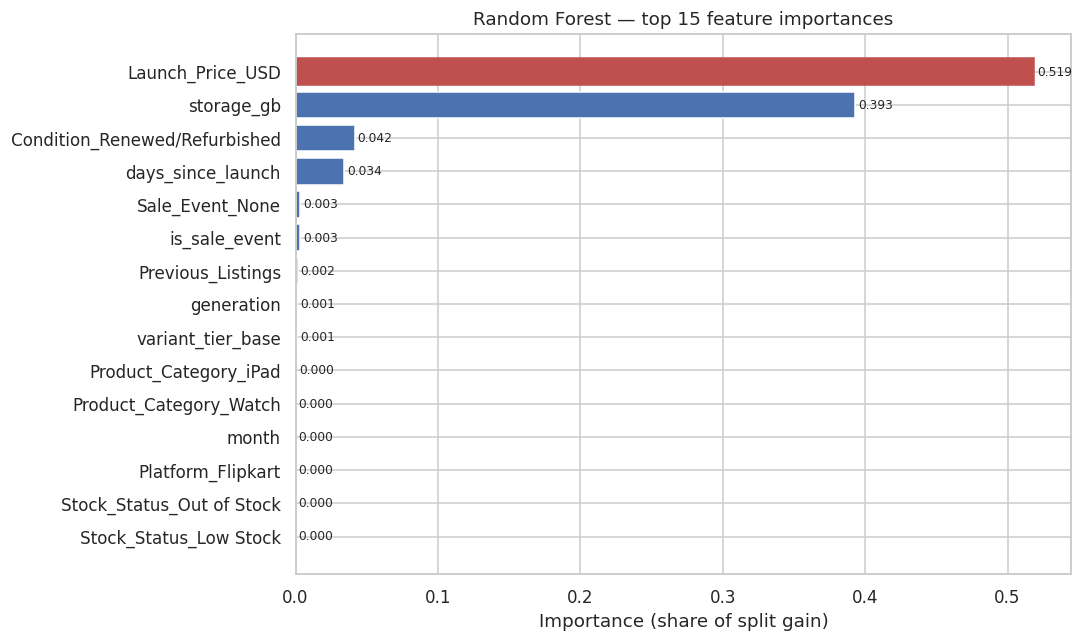

Model: Random Forest — Continuous Features
Train RMSE: $16.80
Test RMSE:  $37.61
RMSE gap:   $20.80
Train MAE:  $10.06
Test MAE:   $23.33
MAE gap:    $13.27
Train R²:   0.9987
Test R²:    0.9932
R² gap:     0.0054


In [24]:
# Feature importance — chart
top = feature_importance.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top['Feature'], top['Importance'], color='#4c72b0')
bars[-1].set_color('#c0504d')  # highlight the most important feature
for bar, v in zip(bars, top['Importance']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
ax.set_title('Random Forest — top 15 feature importances')
ax.set_xlabel('Importance (share of split gain)')
plt.tight_layout()
plt.show()

result = results_table.iloc[0]
print(f"Model: {result['Model']}")
print(f"Train RMSE: ${result['Train RMSE']:.2f}")
print(f"Test RMSE:  ${result['Test RMSE']:.2f}")
print(f"RMSE gap:   ${result['RMSE Gap']:.2f}")
print(f"Train MAE:  ${result['Train MAE']:.2f}")
print(f"Test MAE:   ${result['Test MAE']:.2f}")
print(f"MAE gap:    ${result['MAE Gap']:.2f}")
print(f"Train R²:   {result['Train R²']:.4f}")
print(f"Test R²:    {result['Test R²']:.4f}")
print(f"R² gap:     {result['R² Gap']:.4f}")

# Conclusion

This workflow removes temporal leakage from marketplace-frequency construction and evaluates one continuous-feature Random Forest model:

1. `Previous_Listings` counts only listings from strictly earlier dates.
2. The model is trained on observations before August 1, 2025 and tested on later observations.
3. Encoding and missing-value replacement are learned from the training data only.
4. RMSE, MAE, and R² are reported for both train and test sets, along with train/test gaps.
5. The iPhone 17 is evaluated separately as a completely unseen product.
6. No quintile scoring or quintile-based evaluation is included.
